# Session 3 Essentials of Machine Learning and Deep Learning Technologies

This session introduces essential machine learning (ML) and deep learning (DL) ideas, then applies them through three compact case studies.

**Learning goals:**

- classify AI applications by data modality
- distinguish regression, classification and clustering
- explain common ML methods, including K-means and multilayer perceptrons
- follow the standard `scikit-learn` workflow
- select the appropriate `scikit-learn` estimator for a task
- build preprocessing and modelling pipelines
- compare classical ML models with a simple neural network

**Prerequisites:**

- basic Python and pandas
- ability to run notebook cells in order
- familiarity with rows, columns and DataFrames

## Outline

1. AI applications by data modality
2. Regression VS Classification VS Clustering
3. Common machine learning methods
   - Linear regression
   - K-nearest neighbours
   - Decision trees
   - Random forests
   - Boosting
   - Multilayer perceptrons
   - K-means
4. Machine learning with `scikit-learn`
5. Case study: Celsius to Fahrenheit linear regression
6. Case study: California housing multi-factor regression
7. Case study: MNIST digit classification model comparison

## 1. AI Applications by Data Modality

A **data modality** is a type or form of data. Data modality and algorithm type are not the same thing: table, image and text tasks can use traditional ML or DL, depending on the problem and available data.

| Data type | AI field | Common applications |
|---|---|---|
| Structured or tabular data | Machine learning | sales forecasting, credit scoring, fraud detection |
| Time-series and sensor data | Forecasting and anomaly detection | demand forecasting, predictive maintenance, equipment monitoring |
| Images and video | Computer vision | object detection, medical imaging, quality inspection |
| Text | Natural language processing (NLP) | translation, document classification, search, chatbots |
| Speech and audio | Speech and audio AI | speech recognition, speech generation, sound classification |
| Multiple modalities | Multimodal AI | visual question answering, video understanding, image–text search |
| Environment states and actions | Reinforcement learning and robotics | robot control, games, autonomous systems |

### AI, ML and DL

- **Artificial intelligence (AI)** is the broad field of creating systems that perform tasks associated with intelligent behaviour.
- **Machine learning (ML)** is a part of AI in which models learn patterns from data.
- **Deep learning (DL)** is a part of ML that uses neural networks with multiple layers.

Structured data often works very well with linear models and tree-based models. Images, language and audio are now commonly processed with deep learning, but the choice should be based on the task rather than the data label alone.

## 2. Regression VS Classification VS Clustering

Regression and classification are **supervised learning** tasks: the training data contains input features `X` and a known target `y`. Clustering is **unsupervised learning**: it searches for groups in `X` without using a target during training.

![Regression, classification and clustering comparison](assets/regression-classification-clustering-principle.svg)

| Aspect | Regression | Classification | Clustering |
|---|---|---|---|
| Learning type | Supervised | Supervised | Unsupervised |
| Target `y` | Continuous numeric value | Category or class label | No target during training |
| Example | house price, demand, temperature | digit, spam/not spam, customer segment | customer groups, document groups, image segments |
| Model output | Predicted number | Predicted class and sometimes a probability | Cluster ID and learnt group structure |
| Example estimators | `LinearRegression`, `RandomForestRegressor` | `LogisticRegression`, `KNeighborsClassifier` | `KMeans`, `DBSCAN` |
| Common metrics | MAE, RMSE, R-squared | accuracy, precision, recall, F1-score | inertia, silhouette score |

**Quick decision rules:**

- Predict a continuous number → **regression**.
- Predict one of several known labels → **classification**.
- Discover groups without known labels → **clustering**.

## 3. Common Machine Learning Methods

Many model families have both regression and classification versions. A useful first comparison considers what the model learns, whether scaling is important, and how easily the result can be explained.

### 3.1 Linear Regression

Linear regression predicts a numeric target by learning one weight for each feature and a bias:

$$
y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

where $x_1, x_2, \ldots, x_n$ are input features, $w_1, w_2, \ldots, w_n$ are learnt weights, and $b$ is the bias or intercept.

It is fast, interpretable and useful as a regression baseline, but a linear model cannot represent every non-linear pattern.

![Linear regression principle](assets/linear-regression-principle.png)

### 3.2 K-nearest Neighbours

K-nearest neighbours (KNN) stores the training examples and predicts from nearby cases.

- **Classification:** nearby neighbours vote for a class.
- **Regression:** nearby target values are averaged.
- **Key consideration:** distance is sensitive to feature scale, so standardisation is usually important.

![K-nearest neighbours principle](assets/knn-principle.png)

### 3.3 Decision Trees

A decision tree repeatedly divides data with simple if/then rules.

- A classification leaf predicts a class.
- A regression leaf predicts a numeric value.
- Trees are interpretable and do not normally require scaling, but a deep tree can overfit.

![Decision tree principle](assets/decision-tree-principle.png)

### 3.4 Random Forests

A random forest trains many different decision trees and combines their predictions.

- Classification forests combine votes.
- Regression forests average numeric predictions.
- Combining less-correlated trees usually generalises better than relying on one tree, although the full forest is less interpretable.

![Random forest principle](assets/random-forest-principle.png)

### 3.5 Boosting

Boosting builds weak learners sequentially. Each new learner focuses on reducing errors left by the current combined model.

For regression, a remaining error can be written as:

```text
residual = actual value − current prediction
```

Boosting can model strong non-linear patterns, but its learning rate, number of learners and tree complexity need careful control.

![Boosting principle](assets/boosting-principle.png)

### 3.6 Multilayer Perceptron (MLP)

An MLP is a feed-forward neural network with an input layer, one or more hidden layers, and an output layer. Every connection has a learnt weight. Hidden neurons combine weighted inputs with a bias and an activation function, allowing the network to model non-linear relationships.

- `MLPRegressor` predicts numeric values.
- `MLPClassifier` predicts classes.
- Feature scaling is normally important.
- More hidden layers or neurons increase capacity, but also increase training complexity and overfitting risk.
- MLPs are less interpretable than linear models or small decision trees.

![Multilayer perceptron architecture](assets/mlp-neural-network-basics.svg)

### 3.7 K-means

K-means is an **unsupervised clustering** method. It divides observations into `k` clusters by repeatedly assigning each observation to the nearest centroid and then updating the centroids.

```text
Choose k centroids → assign observations → update centroids → repeat
```

![K-means clustering process](assets/kmeans-clustering-principle.svg)

- The model learns from `X` only; there is no target `y` during fitting.
- Feature scaling is usually important because K-means uses distance.
- `n_clusters` must be chosen before training.
- K-means works best when clusters are compact and reasonably well separated.
- Inertia and silhouette score can help compare different values of `k`.

### Method comparison

| Method | Regression | Classification | Clustering | Scale features? | Main strength | Main limitation |
|---|:---:|:---:|:---:|---|---|---|
| Linear regression | Yes | No | No | Often useful | simple and interpretable | linear relationships only |
| K-nearest neighbours | Yes | Yes | No | **Yes** | intuitive local predictions | slow prediction on large data |
| Decision tree | Yes | Yes | No | Usually no | readable rules | can overfit |
| Random forest | Yes | Yes | No | Usually no | strong general-purpose baseline | less interpretable than one tree |
| Boosting | Yes | Yes | No | Usually no for tree boosting | strong performance on tabular data | sensitive to tuning |
| MLP | Yes | Yes | No | **Yes** | flexible non-linear modelling | training and interpretation are harder |
| K-means | No | No | Yes | **Yes** | simple and efficient grouping | must choose `k`; prefers compact clusters |

## 4. Machine Learning with scikit-learn

### 4.1 Standard ML workflow

```text
[1] Prepare and inspect data with pandas
                ↓
[2] Define X and, for supervised learning, y
                ↓
[3] Split training and test data when evaluating predictions
                ↓
[4] Build a preprocessing and model pipeline
                ↓
[5] Fit: fit(X_train, y_train) or fit(X)
                ↓
[6] Predict values, classes or clusters
                ↓
[7] Evaluate with task-appropriate metrics
```

For supervised learning, the test set stays unseen during training. Any learnt preprocessing, such as scaling or imputation, must be fitted on training data only. Clustering usually fits on `X` without `y`; its evaluation depends on whether the aim is grouping, exploration or downstream prediction.

### 4.2 Core scikit-learn functions

Most `scikit-learn` models follow the same estimator interface.

| Function | What it does |
|---|---|
| `fit(X, y)` | learns from features and known targets in supervised learning |
| `fit(X)` | learns structure from features in unsupervised learning |
| `predict(X)` | returns predicted values, classes or cluster IDs |
| `predict_proba(X)` | returns class probabilities for classifiers that support it |
| `transform(X)` | applies a learnt preprocessing or representation transformation |
| `fit_transform(X)` | learns and applies a transformation |
| `score(X, y)` | returns the estimator's default metric |
| `make_pipeline(...)` | chains preprocessing and modelling steps |
| `named_steps` | provides access to fitted steps inside a pipeline |

Plain language: `fit` is where learning happens, `predict` is where the model is used, and metrics tell us whether its output is useful.

### 4.3 scikit-learn estimators for different ML methods

In `scikit-learn`, a model is represented by an **estimator class**. Regression and classification versions of the same method normally have similar names and share the `fit` and `predict` interface.

| ML method | Regression estimator | Classification estimator | Clustering estimator | Main module |
|---|---|---|---|---|
| Linear model | `LinearRegression` | `LogisticRegression` | — | `sklearn.linear_model` |
| K-nearest neighbours | `KNeighborsRegressor` | `KNeighborsClassifier` | — | `sklearn.neighbors` |
| Decision tree | `DecisionTreeRegressor` | `DecisionTreeClassifier` | — | `sklearn.tree` |
| Random forest | `RandomForestRegressor` | `RandomForestClassifier` | — | `sklearn.ensemble` |
| Gradient boosting | `GradientBoostingRegressor` | `GradientBoostingClassifier` | — | `sklearn.ensemble` |
| Multilayer perceptron | `MLPRegressor` | `MLPClassifier` | — | `sklearn.neural_network` |
| K-means | — | — | `KMeans` | `sklearn.cluster` |

Typical usage:

```python
model.fit(X_train, y_train)   # regression or classification
predictions = model.predict(X_test)

clusters = KMeans(n_clusters=3, random_state=42)
cluster_ids = clusters.fit_predict(X)
```

Models that depend on distance or gradient-based optimisation can be placed after `StandardScaler()` in a pipeline.

## 5. Case Study — Celsius to Fahrenheit Linear Regression

The exact conversion is `Fahrenheit = Celsius × 1.8 + 32`. The local dataset contains small measurement errors, so a model should learn a slope and intercept close to—but not exactly—the known formula.

   celsius  fahrenheit
0      -20        -3.7
1      -15         5.1
2      -10        13.6
3       -5        23.3
4        0        31.4


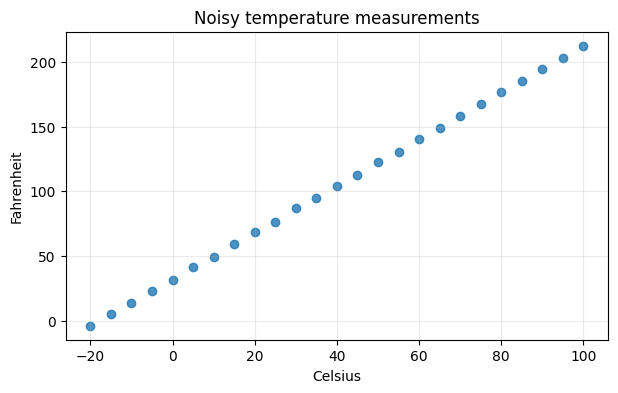

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Section 5 reads only the local temperature dataset.
temperature = pd.read_csv("sample_data/celsius_fahrenheit_noisy.csv")
print(temperature.head())

plt.figure(figsize=(7, 4))
plt.scatter(temperature["celsius"], temperature["fahrenheit"], alpha=0.8)
plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.title("Noisy temperature measurements")
plt.grid(alpha=0.25)
plt.show()

### Define `X` and `y`, then split

`X` must be a two-dimensional feature table. `y` is the one-dimensional target. The split reserves 20% of the rows for testing.

In [2]:
X_temp = temperature[["celsius"]]
y_temp = temperature["fahrenheit"]

X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_temp_train)}")
print(f"Test rows: {len(X_temp_test)}")

Training rows: 20
Test rows: 5


### Data processing and pipeline

`StandardScaler` is included to demonstrate a reusable preprocessing pipeline. Scaling is not essential for this one-feature linear regression, but the same pattern becomes important for distance-based models and neural networks.

In [3]:
temperature_model = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)

temperature_model.fit(X_temp_train, y_temp_train)
temp_predictions = temperature_model.predict(X_temp_test)

temp_mae = mean_absolute_error(y_temp_test, temp_predictions)
temp_rmse = np.sqrt(mean_squared_error(y_temp_test, temp_predictions))
temp_r2 = r2_score(y_temp_test, temp_predictions)

print(f"MAE: {temp_mae:.2f} °F")
print(f"RMSE: {temp_rmse:.2f} °F")
print(f"R-squared: {temp_r2:.4f}")

MAE: 0.41 °F
RMSE: 0.44 °F
R-squared: 1.0000


### Interpret the learnt relationship

Because the input was standardised inside the pipeline, we convert the fitted coefficient back to the original Celsius scale before comparing it with the exact formula.

Learnt formula: Fahrenheit = 1.8032 × Celsius + 31.9800
Prediction for 37 °C: 98.70 °F
Exact value for 37 °C: 98.60 °F


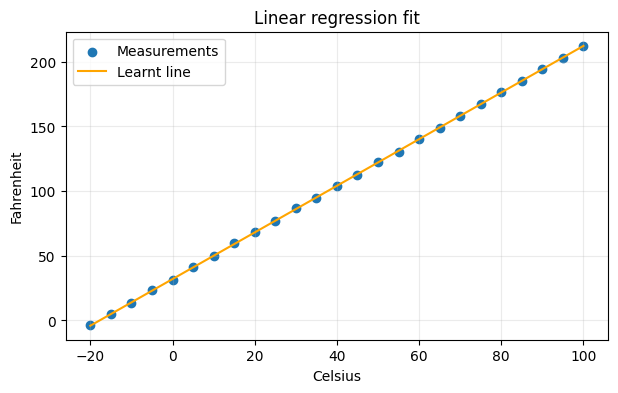

In [4]:
temp_scaler = temperature_model.named_steps["standardscaler"]
temp_regression = temperature_model.named_steps["linearregression"]

learnt_slope = temp_regression.coef_[0] / temp_scaler.scale_[0]
learnt_intercept = temp_regression.intercept_ - (
    temp_regression.coef_[0] * temp_scaler.mean_[0] / temp_scaler.scale_[0]
)

line_x = pd.DataFrame(
    {"celsius": np.linspace(temperature["celsius"].min(), temperature["celsius"].max(), 100)}
)
line_y = temperature_model.predict(line_x)

new_temperature = pd.DataFrame({"celsius": [37]})
model_prediction = temperature_model.predict(new_temperature)[0]
exact_value = 37 * 1.8 + 32

print(f"Learnt formula: Fahrenheit = {learnt_slope:.4f} × Celsius + {learnt_intercept:.4f}")
print(f"Prediction for 37 °C: {model_prediction:.2f} °F")
print(f"Exact value for 37 °C: {exact_value:.2f} °F")

plt.figure(figsize=(7, 4))
plt.scatter(temperature["celsius"], temperature["fahrenheit"], label="Measurements")
plt.plot(line_x["celsius"], line_y, color="orange", label="Learnt line")
plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.title("Linear regression fit")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 6. Case Study — California Housing Multi-Factor Regression

This regression task predicts `median_house_value` from several numeric district features. To keep the case study focused, we remove the text feature and the small number of rows with missing values, then compare a linear model with a one-hidden-layer MLP.

In [5]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor

housing_raw = pd.read_csv("sample_data/california_housing.csv")
housing = housing_raw.drop(columns="ocean_proximity").dropna().reset_index(drop=True)

X_housing = housing.drop(columns="median_house_value")
y_housing = housing["median_house_value"]

X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_housing,
    y_housing,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Original rows: {len(housing_raw):,}")
print(f"Rows after dropping missing values: {len(housing):,}")
print(f"Numeric features: {X_housing.shape[1]}")
housing.head(3)

Original rows: 20,640
Rows after dropping missing values: 20,433
Numeric features: 8


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0


### Build, fit and compare the models

Both models standardise their input features. The MLP also standardises the target internally with `TransformedTargetRegressor`, then automatically converts predictions back to dollars.

In [6]:
linear_housing_model = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)

mlp_housing_model = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32,),
            max_iter=250,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    ),
    transformer=StandardScaler(),
)

housing_models = {
    "Linear regression": linear_housing_model,
    "MLP (one hidden layer)": mlp_housing_model,
}

housing_predictions = {}
housing_results = []

for model_name, model in housing_models.items():
    model.fit(X_house_train, y_house_train)
    predictions = model.predict(X_house_test)
    housing_predictions[model_name] = predictions
    housing_results.append(
        {
            "model": model_name,
            "MAE ($)": mean_absolute_error(y_house_test, predictions),
            "RMSE ($)": np.sqrt(mean_squared_error(y_house_test, predictions)),
            "R-squared": r2_score(y_house_test, predictions),
        }
    )

housing_results_df = pd.DataFrame(housing_results).sort_values("MAE ($)")
housing_results_df.style.format(
    {"MAE ($)": "${:,.0f}", "RMSE ($)": "${:,.0f}", "R-squared": "{:.4f}"}
)

,model,MAE ($),RMSE ($),R-squared
1,MLP (one hidden layer),"$39,754","$57,577",0.7576
0,Linear regression,"$51,373","$70,156",0.6401


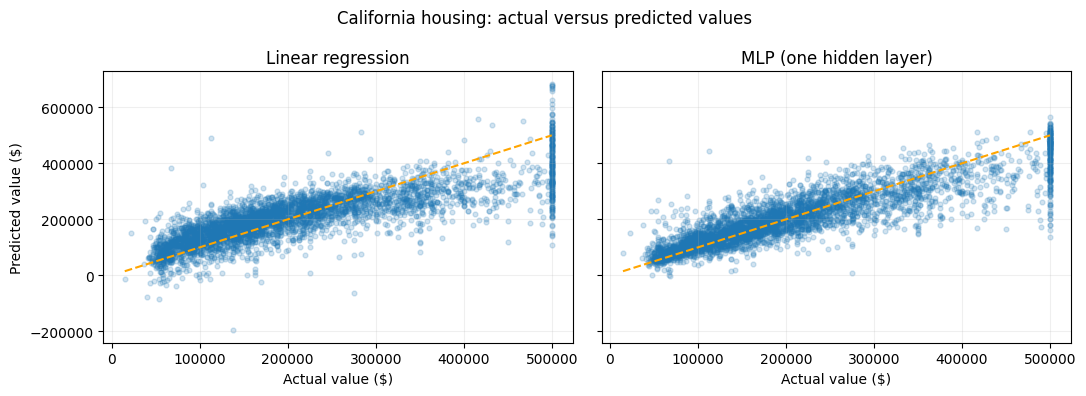

Actual value for one district: $245,800
Linear regression: $197,058
MLP (one hidden layer): $214,311


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
plot_limits = [y_house_test.min(), y_house_test.max()]

for axis, (model_name, predictions) in zip(axes, housing_predictions.items()):
    axis.scatter(y_house_test, predictions, alpha=0.2, s=12)
    axis.plot(plot_limits, plot_limits, color="orange", linestyle="--")
    axis.set_title(model_name)
    axis.set_xlabel("Actual value ($)")
    axis.grid(alpha=0.2)

axes[0].set_ylabel("Predicted value ($)")
fig.suptitle("California housing: actual versus predicted values")
plt.tight_layout()
plt.show()

example_district = X_house_test.iloc[[0]]
example_actual = y_house_test.iloc[0]
print(f"Actual value for one district: ${example_actual:,.0f}")
for model_name, model in housing_models.items():
    print(f"{model_name}: ${model.predict(example_district)[0]:,.0f}")

## 7. Case Study — MNIST Digit Classification Model Comparison

Each row contains a digit label followed by 784 pixel values for a `28 × 28` greyscale image. We use a balanced classroom subset, scale pixels to `0–1`, and compare two MLPs with boosting and KNN.

In [8]:
mnist_columns = ["label"] + [f"pixel_{index}" for index in range(784)]
mnist = pd.read_csv("sample_data/mnist_train_small.csv", header=None, names=mnist_columns)

# Use a smaller stratified subset to keep all four model comparisons classroom-friendly.
mnist_subset, _ = train_test_split(
    mnist,
    train_size=3_000,
    stratify=mnist["label"],
    random_state=RANDOM_STATE,
)

X_digits = mnist_subset.drop(columns="label").to_numpy(dtype=float) / 255.0
y_digits = mnist_subset["label"].to_numpy(dtype=int)

X_digit_train, X_digit_test, y_digit_train, y_digit_test = train_test_split(
    X_digits,
    y_digits,
    test_size=0.2,
    stratify=y_digits,
    random_state=RANDOM_STATE,
)

print(f"Local MNIST rows: {len(mnist):,}")
print(f"Classroom subset: {len(mnist_subset):,}")
print(f"Training shape: {X_digit_train.shape}")
print(f"Test shape: {X_digit_test.shape}")
mnist_subset["label"].value_counts().sort_index().rename("rows").to_frame().T

Local MNIST rows: 6,000
Classroom subset: 3,000
Training shape: (2400, 784)
Test shape: (600, 784)


label,0,1,2,3,4,5,6,7,8,9
rows,300,300,300,300,300,300,300,300,300,300


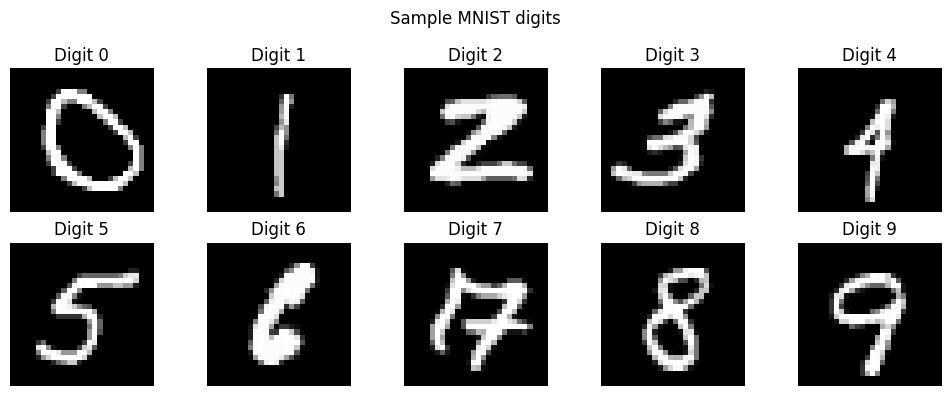

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, axis in enumerate(axes.flat):
    sample_index = np.flatnonzero(y_digits == digit)[0]
    axis.imshow(X_digits[sample_index].reshape(28, 28), cmap="gray")
    axis.set_title(f"Digit {digit}")
    axis.axis("off")

plt.suptitle("Sample MNIST digits")
plt.tight_layout()
plt.show()

### Train and evaluate four classifiers

Accuracy measures the share of correct predictions. Macro F1 calculates F1 separately for each digit and gives every digit equal importance.

In [10]:
from time import perf_counter

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

digit_models = {
    "MLP: one hidden layer": MLPClassifier(
        hidden_layer_sizes=(64,),
        max_iter=35,
        batch_size=128,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    "MLP: two hidden layers": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=35,
        batch_size=128,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        max_iter=12,
        learning_rate=0.12,
        max_leaf_nodes=15,
        max_bins=32,
        random_state=RANDOM_STATE,
    ),
    "K-nearest neighbours": KNeighborsClassifier(n_neighbors=3, weights="distance"),
}

digit_predictions = {}
digit_results = []

for model_name, model in digit_models.items():
    start_time = perf_counter()
    model.fit(X_digit_train, y_digit_train)
    predictions = model.predict(X_digit_test)
    elapsed = perf_counter() - start_time
    digit_predictions[model_name] = predictions
    digit_results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_digit_test, predictions),
            "macro F1": f1_score(y_digit_test, predictions, average="macro"),
            "fit + predict (s)": elapsed,
        }
    )

digit_results_df = pd.DataFrame(digit_results).sort_values("macro F1", ascending=False)
digit_results_df.style.format(
    {"accuracy": "{:.4f}", "macro F1": "{:.4f}", "fit + predict (s)": "{:.2f}"}
)

,model,accuracy,macro F1,fit + predict (s)
3,K-nearest neighbours,0.9050,0.9042,0.03
0,MLP: one hidden layer,0.8967,0.8966,0.29
1,MLP: two hidden layers,0.8950,0.8941,0.23
2,Histogram gradient boosting,0.8800,0.8789,1.69


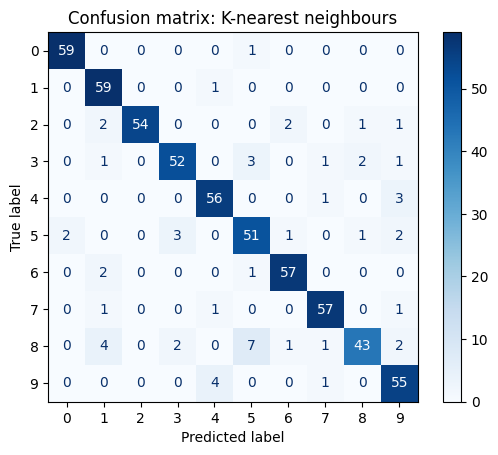

Best model by macro F1: K-nearest neighbours

              precision    recall  f1-score   support

           0       0.97      0.98      0.98        60
           1       0.86      0.98      0.91        60
           2       1.00      0.90      0.95        60
           3       0.91      0.87      0.89        60
           4       0.90      0.93      0.92        60
           5       0.81      0.85      0.83        60
           6       0.93      0.95      0.94        60
           7       0.93      0.95      0.94        60
           8       0.91      0.72      0.80        60
           9       0.85      0.92      0.88        60

    accuracy                           0.91       600
   macro avg       0.91      0.90      0.90       600
weighted avg       0.91      0.91      0.90       600



In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_digit_model = digit_results_df.iloc[0]["model"]
best_digit_predictions = digit_predictions[best_digit_model]

ConfusionMatrixDisplay.from_predictions(
    y_digit_test,
    best_digit_predictions,
    cmap="Blues",
    values_format="d",
)
plt.title(f"Confusion matrix: {best_digit_model}")
plt.show()

print(f"Best model by macro F1: {best_digit_model}")
print()
print(classification_report(y_digit_test, best_digit_predictions))

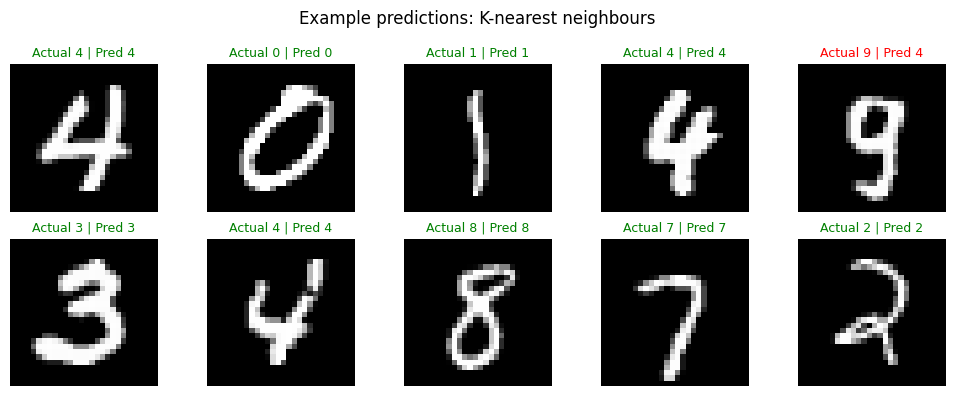

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for axis, image, actual, predicted in zip(
    axes.flat,
    X_digit_test[:10],
    y_digit_test[:10],
    best_digit_predictions[:10],
):
    axis.imshow(image.reshape(28, 28), cmap="gray")
    colour = "green" if actual == predicted else "red"
    axis.set_title(f"Actual {actual} | Pred {predicted}", color=colour, fontsize=9)
    axis.axis("off")

plt.suptitle(f"Example predictions: {best_digit_model}")
plt.tight_layout()
plt.show()